,source,destination,matrix_weight,vector_weight
0,0,1,0.467316,0.467316
1,0,2,0.769871,0.769871
2,0,3,0.925960,0.925960
3,0,4,0.669746,0.669746
4,0,5,0.533876,0.533876
5,1,2,0.607006,0.607006
6,1,3,0.502932,0.502932
7,1,4,0.697751,0.697751
8,1,5,0.868236,0.868236
9,2,3,0.828547,0.828547


,percentile,threshold
0,10,0.515310
1,20,0.566427
2,40,0.683976
3,80,0.830454


Selected percentile: 80
Threshold: 0.830454290
Vectorization correct: True
Reconstruction correct: True
Symmetric: True
Zero diagonal: True


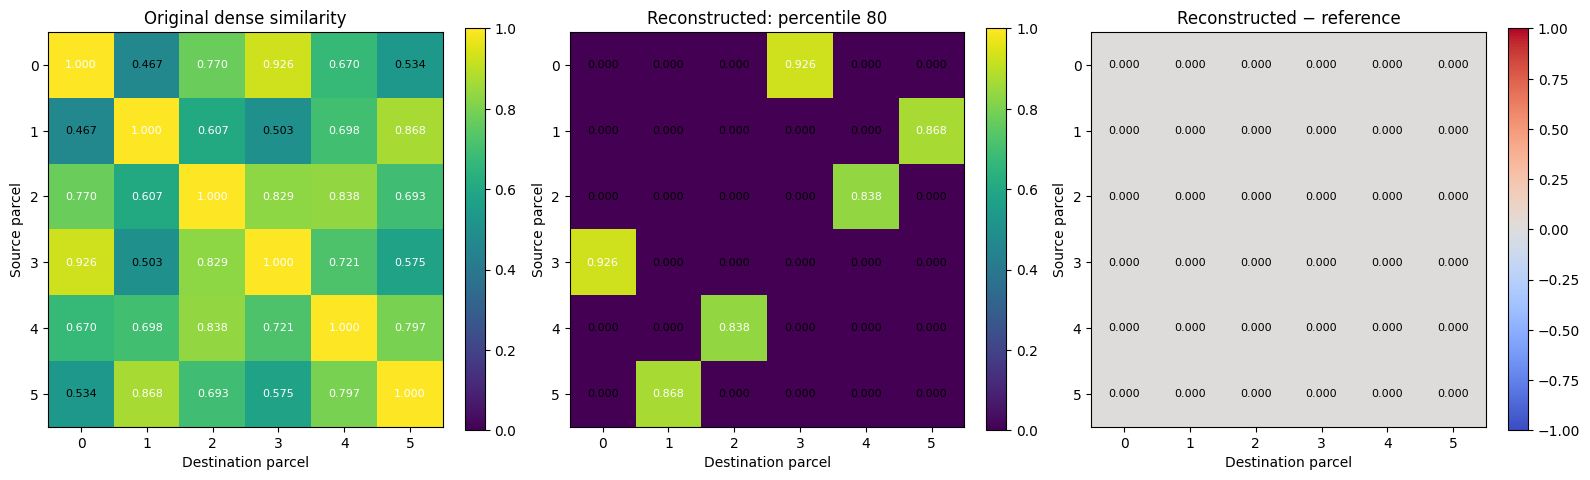

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from scipy.sparse import coo_matrix


# Locate project root regardless of notebook location.
PROJECT_ROOT = next(
    folder
    for folder in (Path.cwd(), *Path.cwd().parents)
    if (folder / "scripts/graph_building/thresholded_similarity_graph.py").is_file()
)

sys.path.insert(0, str(PROJECT_ROOT / "scripts/graph_building"))

from thresholded_similarity_graph import compute_upper_rows, PERCENTILES
from wasserstein_distance_graph2 import (
    SIM_FORMULA_EXP,
    _compute_block,
    _to_quantile_grid,
)


# Small real-data example.
SUBJECT_ID = "sub-0001"
N_PARCELS = 6
N_PROCESSES = 2
BLOCK_SIZE = 2

subject_folder = (
    PROJECT_ROOT
    / "outputs"
    / "jacobian_parcel_vectors"
    / SUBJECT_ID
)

data = np.fromfile(
    subject_folder / "parcel_vectors.dat",
    dtype=np.float32,
)
offsets = np.fromfile(
    subject_folder / "parcel_offsets.dat",
    dtype=np.int64,
)

quantile_matrix = np.stack(
    [
        _to_quantile_grid(data[start:end])
        for start, end in zip(
            offsets[:N_PARCELS],
            offsets[1 : N_PARCELS + 1],
        )
    ]
)

n_parcels = quantile_matrix.shape[0]


# 1. Original dense similarity matrix.
_, _, original_matrix = _compute_block(
    0,
    n_parcels,
    quantile_matrix,
    SIM_FORMULA_EXP,
)


# 2. Exact same parallel block logic as the script.
blocks = [
    (start, min(start + BLOCK_SIZE, n_parcels - 1))
    for start in range(0, n_parcels - 1, BLOCK_SIZE)
]

block_rows = Parallel(
    n_jobs=N_PROCESSES,
    prefer="processes",
)(
    delayed(compute_upper_rows)(
        i_start,
        i_end,
        quantile_matrix,
    )
    for i_start, i_end in blocks
)

upper_rows = [
    row
    for rows_in_block in block_rows
    for row in rows_in_block
]

all_upper_values = np.concatenate(upper_rows)


# 3. Show the matrix-to-vector mapping.
upper_indices = np.triu_indices(n_parcels, 1)

vector_table = pd.DataFrame(
    {
        "source": upper_indices[0],
        "destination": upper_indices[1],
        "matrix_weight": original_matrix[upper_indices],
        "vector_weight": all_upper_values,
    }
)

display(vector_table)


# 4. Calculate every percentile exactly.
thresholds = {
    percentile: np.percentile(all_upper_values, percentile)
    for percentile in PERCENTILES
}

display(
    pd.DataFrame(
        {
            "percentile": list(thresholds),
            "threshold": list(thresholds.values()),
        }
    )
)


# Match current script behavior: use the final percentile.
selected_percentile = PERCENTILES[-1]
threshold = thresholds[selected_percentile]

print(f"Selected percentile: {selected_percentile}")
print(f"Threshold: {threshold:.9f}")


# 5. Same thresholding and reconstruction logic.
rows, cols, weights = [], [], []

for i, upper_values in enumerate(upper_rows):
    keep = upper_values >= threshold
    js = np.flatnonzero(keep) + i + 1
    kept_values = upper_values[keep].astype(
        np.float32,
        copy=False,
    )

    rows.extend(
        (
            np.full(js.size, i, dtype=np.int32),
            js.astype(np.int32, copy=False),
        )
    )
    cols.extend(
        (
            js.astype(np.int32, copy=False),
            np.full(js.size, i, dtype=np.int32),
        )
    )
    weights.extend((kept_values, kept_values))

reconstructed_matrix = coo_matrix(
    (
        np.concatenate(weights),
        (
            np.concatenate(rows),
            np.concatenate(cols),
        ),
    ),
    shape=(n_parcels, n_parcels),
    dtype=np.float32,
).toarray()


# 6. Independent reference constructed directly from the dense matrix.
reference_matrix = np.where(
    original_matrix >= threshold,
    original_matrix,
    0.0,
)

# Self-similarity is excluded.
np.fill_diagonal(reference_matrix, 0.0)


# 7. Validation.
print(
    "Vectorization correct:",
    np.array_equal(
        all_upper_values,
        original_matrix[upper_indices],
    ),
)

print(
    "Reconstruction correct:",
    np.array_equal(
        reconstructed_matrix,
        reference_matrix,
    ),
)

print(
    "Symmetric:",
    np.array_equal(
        reconstructed_matrix,
        reconstructed_matrix.T,
    ),
)

print(
    "Zero diagonal:",
    np.count_nonzero(
        np.diag(reconstructed_matrix)
    ) == 0,
)


# 8. Visual inspection.
difference = reconstructed_matrix - reference_matrix

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
)

images = [
    (
        original_matrix,
        "Original dense similarity",
        "viridis",
        0,
        1,
    ),
    (
        reconstructed_matrix,
        f"Reconstructed: percentile {selected_percentile}",
        "viridis",
        0,
        1,
    ),
    (
        difference,
        "Reconstructed − reference",
        "coolwarm",
        -1,
        1,
    ),
]

for ax, (matrix, title, cmap, vmin, vmax) in zip(axes, images):
    image = ax.imshow(
        matrix,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_title(title)
    ax.set_xlabel("Destination parcel")
    ax.set_ylabel("Source parcel")
    ax.set_xticks(range(n_parcels))
    ax.set_yticks(range(n_parcels))

    for row in range(n_parcels):
        for column in range(n_parcels):
            ax.text(
                column,
                row,
                f"{matrix[row, column]:.3f}",
                ha="center",
                va="center",
                fontsize=8,
                color=(
                    "white"
                    if abs(matrix[row, column]) > 0.55
                    else "black"
                ),
            )

    fig.colorbar(image, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()